In [20]:
import networkx as nx
import pandas as pd
import duckdb as db

arestas = db.sql("SELECT child_id, parent_id FROM '../base_de_dados/agrovoc_hortalicas_arestas.parquet'").df()

G = nx.DiGraph()
G.add_edges_from(arestas.values)

print("nos:", G.number_of_nodes(), "| arestas:", G.number_of_edges())

print("e um DAG?", nx.is_directed_acyclic_graph(G))
com_dois_pais = [n for n in G if G.out_degree(n) > 1]
print("nos com mais de um pai:", len(com_dois_pais))
print("logo, e arvore?", all(G.out_degree(n) <= 1 for n in G))



nos: 121 | arestas: 120
e um DAG? True
nos com mais de um pai: 1
logo, e arvore? False


In [21]:
arestas.head(5)

,child_id,parent_id
0,c_14477,c_8174
1,c_9786,c_8174
2,c_3376,c_8174
3,c_12151,c_3376
4,c_779f4094,c_12151


In [22]:
db.sql("""
    SELECT child_id, COUNT(*) AS num_pais
    FROM '../base_de_dados/agrovoc_hortalicas_arestas.csv'
    GROUP BY child_id
    HAVING COUNT(*) > 1
    ORDER BY num_pais DESC
""").show()

┌──────────┬──────────┐
│ child_id │ num_pais │
│ varchar  │  int64   │
├──────────┼──────────┤
│ c_7552   │        2 │
└──────────┴──────────┘



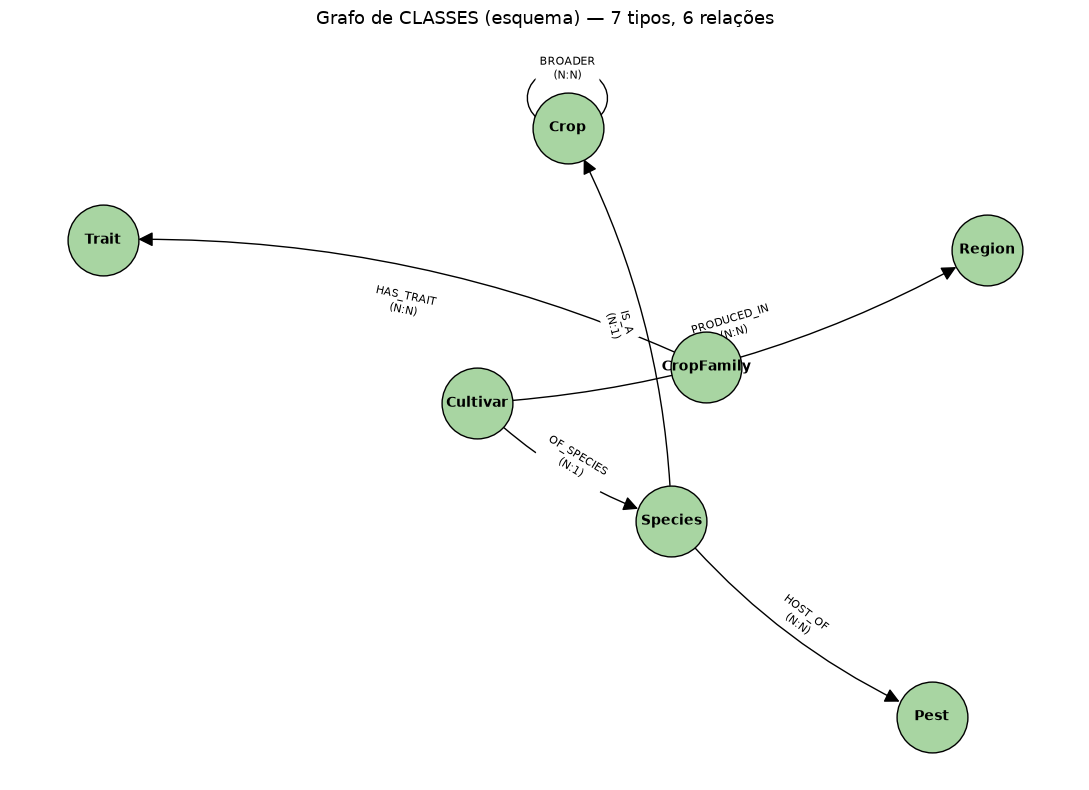

In [23]:
import networkx as nx
import matplotlib.pyplot as plt

# --- GRAFO DE CLASSES ---
G_classes = nx.DiGraph()

tipos = ["Crop", "CropFamily", "Species", "Cultivar", "Region", "Trait", "Pest"]
G_classes.add_nodes_from(tipos)

# (origem, destino, relação, cardinalidade)
relacoes = [
    ("Crop",      "Crop",    "BROADER",     "N:N"),
    ("Species",   "Crop",    "IS_A",        "N:1"),
    ("Cultivar",  "Species", "OF_SPECIES",  "N:1"),
    ("Cultivar",  "Region",  "PRODUCED_IN", "N:N"),
    ("CropFamily","Trait",   "HAS_TRAIT",   "N:N"),
    ("Species",   "Pest",    "HOST_OF",     "N:N"),
]

for o, d, rel, card in relacoes:
    G_classes.add_edge(o, d, label=f"{rel}\n({card})")

# --- DESENHO ---
pos = nx.spring_layout(G_classes, seed=42, k=1.5)

plt.figure(figsize=(11, 8))
nx.draw_networkx_nodes(G_classes, pos, node_size=2600,
                       node_color="#a8d5a2", edgecolors="black")
nx.draw_networkx_labels(G_classes, pos, font_size=10, font_weight="bold")

# arestas normais + o laço BROADER (self-loop)
nx.draw_networkx_edges(G_classes, pos, node_size=2600,
                       arrowsize=22, connectionstyle="arc3,rad=0.12")

edge_labels = nx.get_edge_attributes(G_classes, "label")
nx.draw_networkx_edge_labels(G_classes, pos, edge_labels=edge_labels,
                             font_size=8, label_pos=0.5)

plt.title("Grafo de CLASSES (esquema) — 7 tipos, 6 relações", fontsize=13)
plt.axis("off")
plt.tight_layout()
plt.savefig("grafo_classes.png", dpi=150)
plt.show()

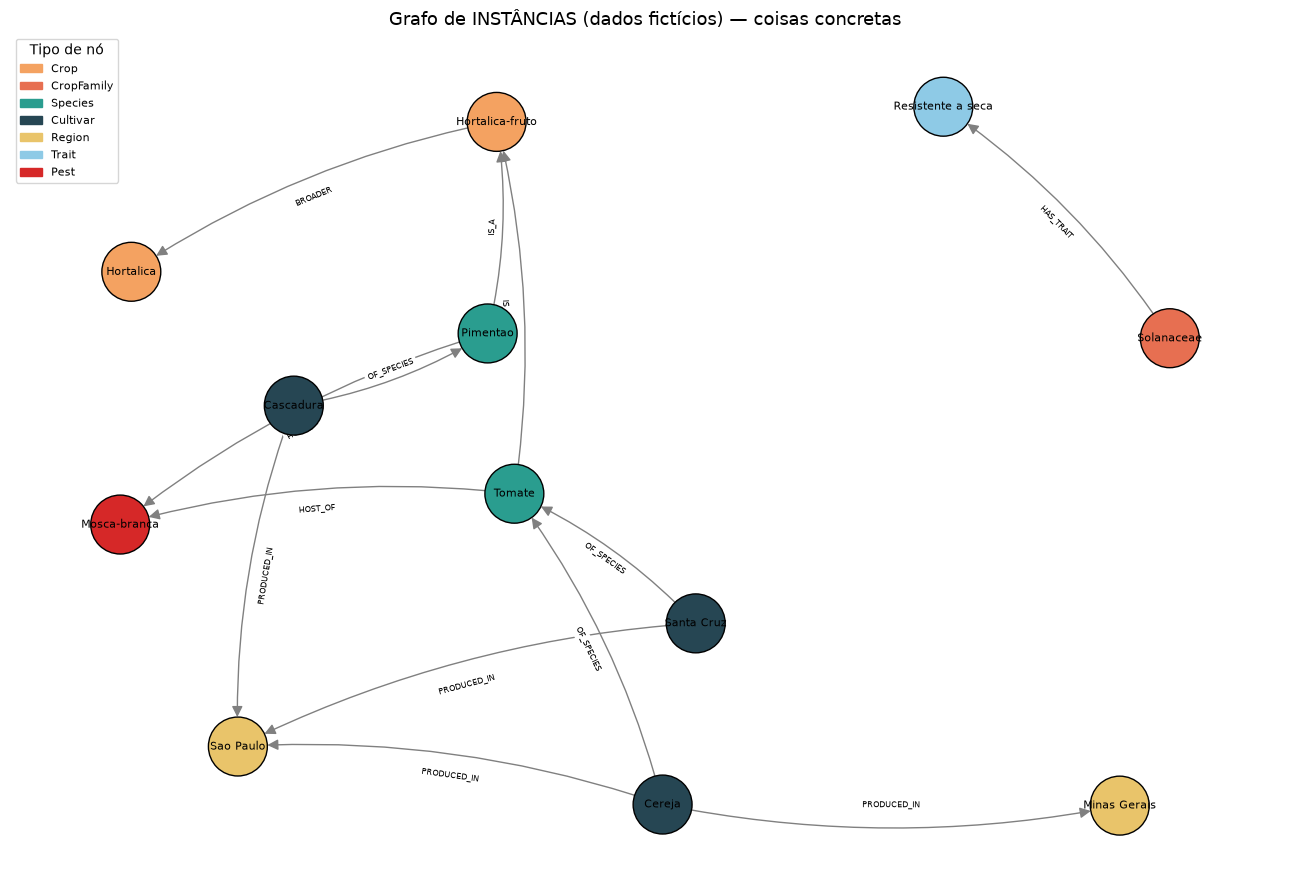

In [24]:
import networkx as nx
import matplotlib.pyplot as plt

G_inst = nx.DiGraph()

# cor por tipo de instância
tipo_cor = {
    "Crop": "#f4a261", "CropFamily": "#e76f51", "Species": "#2a9d8f",
    "Cultivar": "#264653", "Region": "#e9c46a", "Trait": "#8ecae6",
    "Pest": "#d62828",
}

# (id, tipo)
nos = [
    # Crops (com hierarquia BROADER entre eles)
    ("Hortalica", "Crop"), ("Hortalica-fruto", "Crop"),
    # CropFamily
    ("Solanaceae", "CropFamily"),
    # Species
    ("Tomate", "Species"), ("Pimentao", "Species"),
    # Cultivars
    ("Santa Cruz", "Cultivar"), ("Cereja", "Cultivar"), ("Cascadura", "Cultivar"),
    # Regions
    ("Sao Paulo", "Region"), ("Minas Gerais", "Region"),
    # Traits
    ("Resistente a seca", "Trait"),
    # Pests
    ("Mosca-branca", "Pest"),
]
for nid, tipo in nos:
    G_inst.add_node(nid, tipo=tipo)

# arestas concretas (cada uma obedece a uma relação da planta baixa)
arestas = [
    ("Hortalica-fruto", "Hortalica", "BROADER"),
    ("Tomate", "Hortalica-fruto", "IS_A"),
    ("Pimentao", "Hortalica-fruto", "IS_A"),
    ("Santa Cruz", "Tomate", "OF_SPECIES"),
    ("Cereja", "Tomate", "OF_SPECIES"),
    ("Cascadura", "Pimentao", "OF_SPECIES"),
    ("Santa Cruz", "Sao Paulo", "PRODUCED_IN"),
    ("Cereja", "Minas Gerais", "PRODUCED_IN"),
    ("Cereja", "Sao Paulo", "PRODUCED_IN"),      # N:N: cultivar em 2 regiões
    ("Cascadura", "Sao Paulo", "PRODUCED_IN"),
    ("Solanaceae", "Resistente a seca", "HAS_TRAIT"),
    ("Tomate", "Mosca-branca", "HOST_OF"),
    ("Pimentao", "Mosca-branca", "HOST_OF"),     # N:N: 2 espécies, 1 praga
]
for o, d, rel in arestas:
    G_inst.add_edge(o, d, label=rel)

# --- DESENHO ---
cores = [tipo_cor[G_inst.nodes[n]["tipo"]] for n in G_inst.nodes]
pos = nx.spring_layout(G_inst, seed=7, k=1.2)

plt.figure(figsize=(13, 9))
nx.draw_networkx_nodes(G_inst, pos, node_size=1800,
                       node_color=cores, edgecolors="black")
nx.draw_networkx_labels(G_inst, pos, font_size=8)
nx.draw_networkx_edges(G_inst, pos, node_size=1800,
                       arrowsize=16, connectionstyle="arc3,rad=0.1",
                       edge_color="gray")
nx.draw_networkx_edge_labels(G_inst, pos,
                             edge_labels=nx.get_edge_attributes(G_inst, "label"),
                             font_size=6)

# legenda de cores por tipo
from matplotlib.patches import Patch
legenda = [Patch(color=c, label=t) for t, c in tipo_cor.items()]
plt.legend(handles=legenda, loc="upper left", fontsize=8, title="Tipo de nó")

plt.title("Grafo de INSTÂNCIAS (dados fictícios) — coisas concretas", fontsize=13)
plt.axis("off")
plt.tight_layout()
plt.savefig("grafo_instancias.png", dpi=150)
plt.show()